# Trajectory with STREAM2
 Stream2 trajectory and extract macrostates

Change the parameters here : 

In [18]:
# === PARAMETERS ===
input_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/seurat_mono_macro.h5ad"
patient = "patient2"
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"
reduction='X_umap' # Reduction on which trajectory learning is based (X_umap, X_pca, X_tsne)
nb_node= 20 # Number of nodes on the trajectory graph
nb_cluster= 10 # Number of cluster on the trajectory graph -> ramification

In [2]:
#!pip uninstall stream2 -y
#!pip install git+https://github.com/pinellolab/STREAM2.git
# Restart the kernel
import stream2 as st2
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
#!pip3 install leidenalg

/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  return modu

In [3]:
adata = sc.read(input_file)

/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/_io/h5ad.py:266: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{


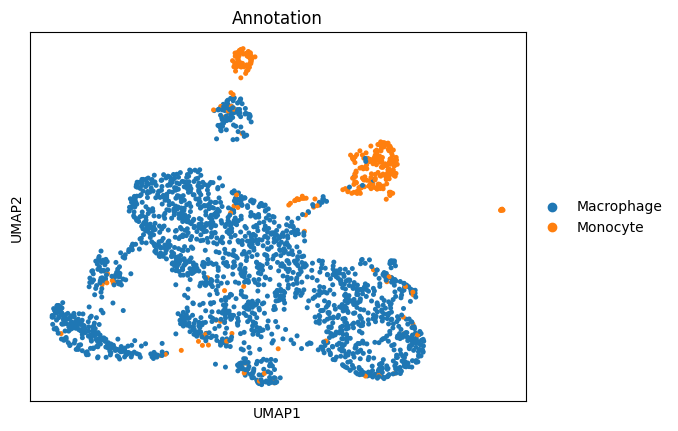

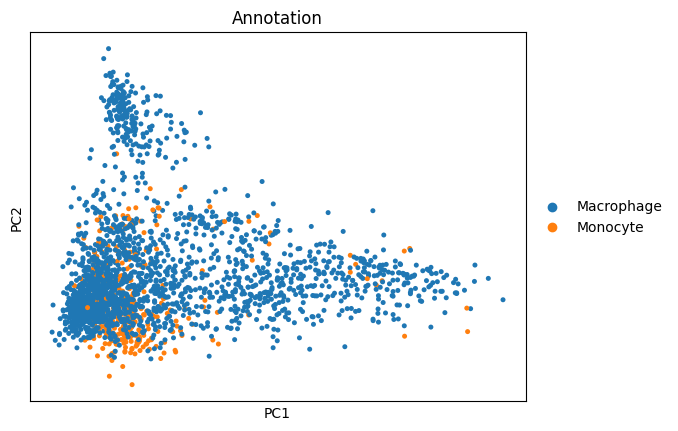

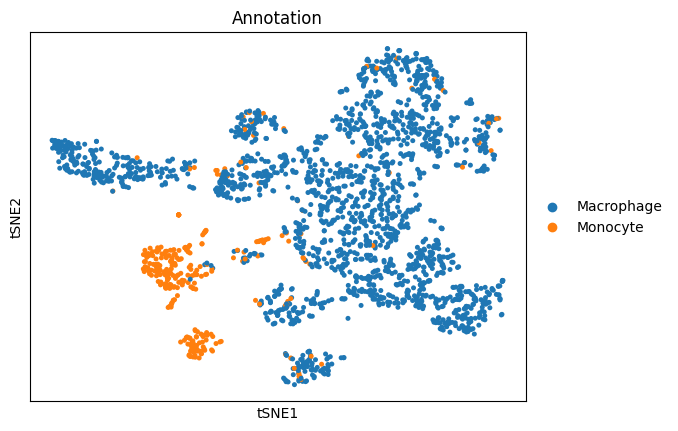

In [4]:
sc.pl.umap(adata,color=['Annotation'])
sc.pl.pca(adata,color=['Annotation'])
sc.pl.tsne(adata,color=['Annotation'])

/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:940: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():


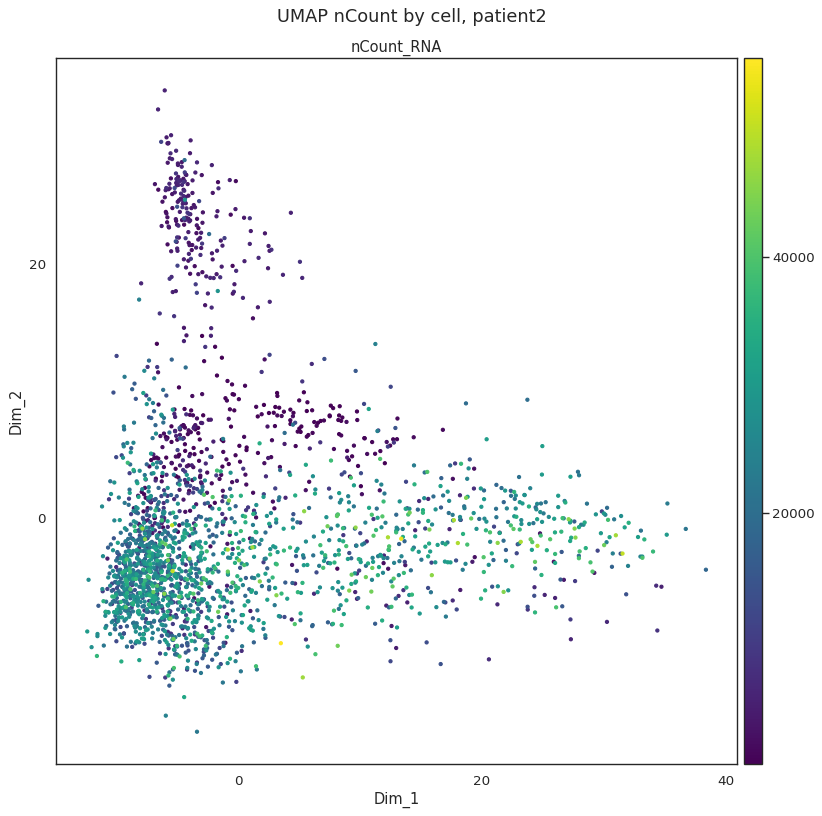

In [5]:
adata.obsm['X_dr'] = adata.obsm['X_pca']
st2.settings.set_figure_params(dpi=80,
                              style='white',
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

st2.pl.dimension_reduction(adata,color=['nCount_RNA'],
                           fig_legend_ncol=2, fig_size=(10,10))
plt.suptitle(f"UMAP nCount by cell, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/ncount_{patient}.png", dpi=300, bbox_inches='tight')

/tmp/ipykernel_28154/3951225322.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


Found 1 components


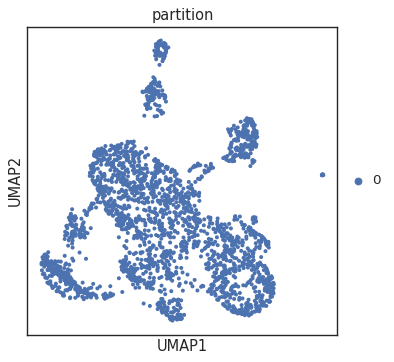

In [6]:
sc.pp.neighbors(adata,use_rep='X_pca')
sc.tl.leiden(adata)
st2.tl.find_disconnected_components(adata,groups='leiden')
sc.pl.umap(adata,color='partition')

<Axes: xlabel='partition'>

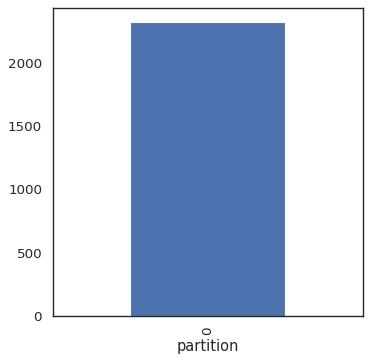

In [7]:
# Many are small clusters which are not adequate for trajectory inference and can be filtered out
# We keep components with more than 500 cells
adata.obs['partition'].value_counts().plot.bar()

Seeding initial graph for each partition...
Learning elastic principal graph for each partition...


/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:1110: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:1110: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():


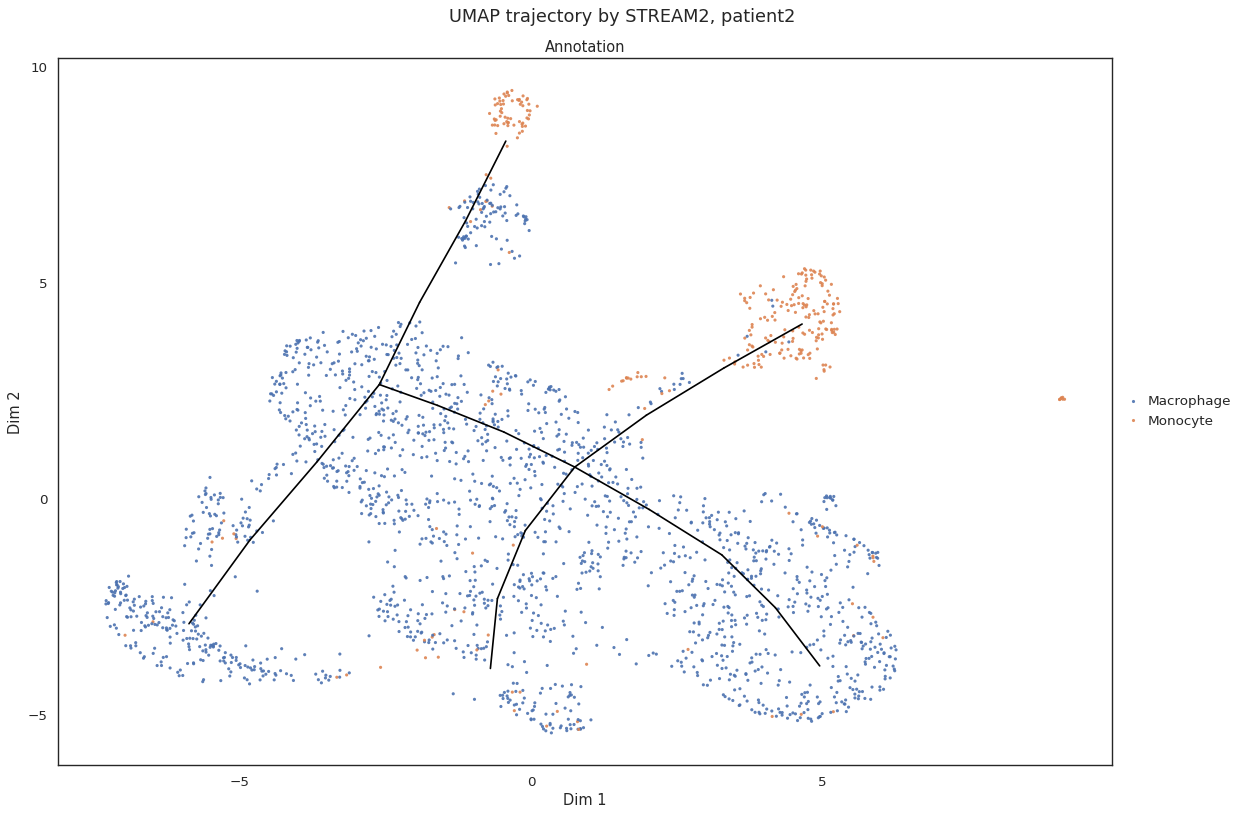

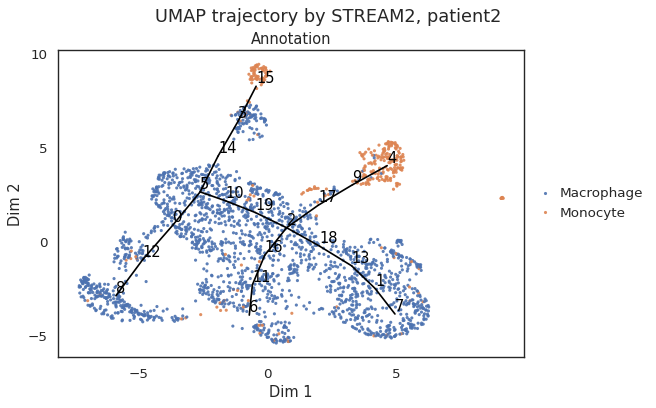

In [19]:
use_partition=['0']
st2.tl.seed_graph(adata, obsm=f"{reduction}", n_clusters=nb_cluster,use_partition=use_partition)
st2.tl.learn_graph(adata, obsm=f"{reduction}", n_nodes=nb_node,epg_alpha=0.01,epg_mu=0.2,use_partition=use_partition)
st2.pl.graph(adata,key='epg',color=['Annotation'],fig_size=(15,10),save_fig=False)
plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/graph_myel_{patient}.png", dpi=300, bbox_inches='tight')
#adata_sub.uns['epg']['leaves']

st2.tl._elpigraph._store_graph_attributes(adata,adata.obsm[f"{reduction}"],'epg')
st2.pl.graph(adata,key='epg',color=['Annotation'],show_text=True,fig_size=(8,5),save_fig=False)
plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/graph_v2_myel_{patient}.png", dpi=300, bbox_inches='tight')

In [20]:
unique_nodes = sorted(adata.obs['epg_node_id'].dropna().unique())

# Mapping node_id in a label (N1, N2...)
epg_to_label = {node: f"N{int(node)}" for node in unique_nodes}

# Macrostate column
adata.obs["macrostate"] = np.nan
adata.obs["macrostate"] = (
    adata.obs["macrostate"]
    .astype("category")
    .cat.add_categories(sorted(epg_to_label.values()))
)

# Assign the macrostate based on the nearest node
for node, label in epg_to_label.items():
    mask = adata.obs['epg_node_id'] == node
    adata.obs.loc[mask, "macrostate"] = label

print(adata.obs['macrostate'].value_counts())

macrostate
N8     223
N7     195
N5     165
N13    162
N4     160
N0     157
N1     157
N11    146
N6     145
N16    119
N19    111
N10     97
N3      94
N2      80
N12     79
N18     67
N15     64
N17     42
N9      29
N14     24
Name: count, dtype: int64


In [10]:
print(adata.obs.columns)
print(adata.obs["macrostate"].head())
print(adata.obs["macrostate"].unique())

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT',
       'nFeature_ADT', 'timepoint', 'doublet_finder', 'percent.mt', 'qc_pass',
       'RNA_snn_res.0.1', 'seurat_clusters', 'RNA.weight', 'ADT.weight',
       'wsnn_res.0.1', 'SingleR', 'predicted.celltype.l1',
       'predicted.celltype.l2', 'predicted.celltype.l3', 'manual_annotation',
       'final_annot', 'Annotation', 'clone_opt', 'GT_opt', 'p_opt', 'p_cnv',
       'compartment_opt', 'leiden', 'partition', 'seed_epg_node_id',
       'seed_epg_node_dist', 'seed_epg_edge_id', 'seed_epg_edge_loc',
       'seed_epg_edge_dist', 'epg_node_id', 'epg_node_dist', 'epg_edge_id',
       'epg_edge_loc', 'epg_edge_dist', 'macrostate'],
      dtype='object')
D1_AAAGAACAGGGCGAGA-1    N15
D1_AAAGAACCACGTTCGG-1    N15
D1_AAAGGTATCTATACTC-1    N15
D1_AAAGTGATCGCCGAGT-1    N16
D1_AACAACCTCATCACAG-1    N16
Name: macrostate, dtype: category
Categories (21, object): ['N0', 'N1', 'N10', 'N11', ..., 'N6', 'N7', 'N8', 'N9']
['N15', 'N16', 'N

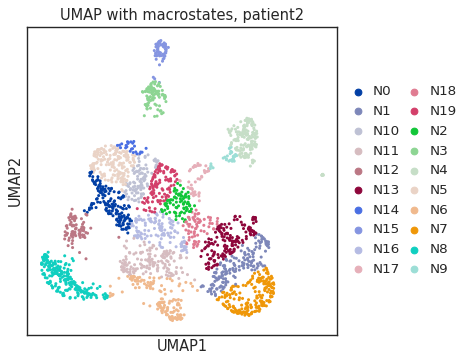

In [21]:
ax = sc.pl.umap(adata,color="macrostate",title=f"UMAP with macrostates, {patient}",size=30,show=False)
ax.figure.savefig(f"{output_directory}/umap_macrostages_{patient}.png", dpi=150, bbox_inches="tight")

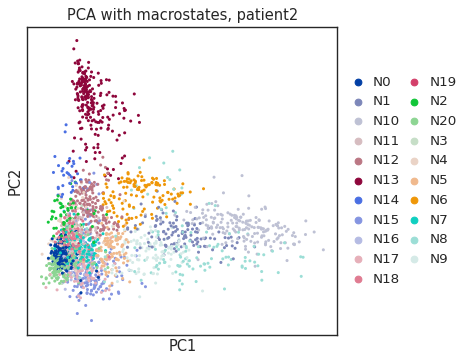

In [12]:
ax = sc.pl.pca(adata,color="macrostate",title=f"PCA with macrostates, {patient}",size=30,show=False)
ax.figure.savefig(f"{output_directory}/pca_macrostages_{patient}.png", dpi=150, bbox_inches="tight")

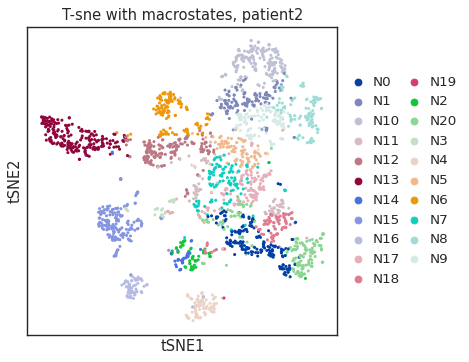

In [13]:
ax = sc.pl.tsne(adata,color="macrostate",title=f"T-sne with macrostates, {patient}",size=30,show=False)
ax.figure.savefig(f"{output_directory}/tsne_macrostages_{patient}.png", dpi=150, bbox_inches="tight")